In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

source:  Source: https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

In [38]:


arff_path = "DryBeanDataset/Dry_Bean_Dataset.arff"
colonnes = [
    'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation',
    'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity',
    'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
    'ShapeFactor3', 'ShapeFactor4', 'Class'
]
with open(arff_path, 'r', encoding='utf-8') as fichier:
    lignes = fichier.readlines()
index_data = next(i for i, ligne in enumerate(lignes) if ligne.strip().lower() == '@data')
df = pd.read_csv(arff_path, comment='%', skiprows=index_data + 1, header=None, names=colonnes)

print("Source : UCI Machine Learning Repository")
print("URL : https://archive.ics.uci.edu/dataset/602/dry+bean+dataset")
print()

print(f"Taille du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()

print("Types des colonnes :")
print(df.dtypes)
print()

print("Distribution des classes :")
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Source : UCI Machine Learning Repository
URL : https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

Taille du dataset : 13611 lignes × 17 colonnes

Types des colonnes :
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

Distribution des classes :
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class
DERMASON    26.05 %
SIRA        19.37 %
SEKER       14.89 %
HOROZ       14.17 %
CALI        11.98 %
BARBUNYA     9.71 %
BOMBAY       3.84 %
Name: proportion, dtype: ob

In [39]:
description = {
    "Area"           : "Surface du grain (pixels)",
    "Perimeter"      : "Périmètre du contour",
    "MajorAxisLength": "Longueur du grand axe",
    "MinorAxisLength": "Longueur du petit axe",
    "AspectRation"   : "Ratio grand axe / petit axe",
    "Eccentricity"   : "Excentricité de l'ellipse",
    "ConvexArea"     : "Surface de l'enveloppe convexe",
    "EquivDiameter"  : "Diamètre équivalent",
    "Extent"         : "Ratio surface grain / boîte englobante",
    "Solidity"       : "Ratio surface grain / surface convexe",
    "roundness"      : "Circularité du grain",
    "Compactness"    : "Compacité relative",
    "ShapeFactor1"   : "Facteur de forme 1",
    "ShapeFactor2"   : "Facteur de forme 2",
    "ShapeFactor3"   : "Facteur de forme 3",
    "ShapeFactor4"   : "Facteur de forme 4",
    "Class"          : "Variété du haricot (7 classes)"
}

for col, desc in description.items():
    print(f"  {col:<20} → {desc}")

print(f"\nNombre de features    : 16")
print(f"Variable cible        : Class")
print(f"Type de tâche         : Classification multiclasses (7 classes)")
print(f"\nAperçu des premières lignes :")
df.head()

  Area                 → Surface du grain (pixels)
  Perimeter            → Périmètre du contour
  MajorAxisLength      → Longueur du grand axe
  MinorAxisLength      → Longueur du petit axe
  AspectRation         → Ratio grand axe / petit axe
  Eccentricity         → Excentricité de l'ellipse
  ConvexArea           → Surface de l'enveloppe convexe
  EquivDiameter        → Diamètre équivalent
  Extent               → Ratio surface grain / boîte englobante
  Solidity             → Ratio surface grain / surface convexe
  roundness            → Circularité du grain
  Compactness          → Compacité relative
  ShapeFactor1         → Facteur de forme 1
  ShapeFactor2         → Facteur de forme 2
  ShapeFactor3         → Facteur de forme 3
  ShapeFactor4         → Facteur de forme 4
  Class                → Variété du haricot (7 classes)

Nombre de features    : 16
Variable cible        : Class
Type de tâche         : Classification multiclasses (7 classes)

Aperçu des premières lignes :


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.29,208.18,173.89,1.20,0.55,28715,190.14,0.76,0.99,0.96,0.91,0.01,0.00,0.83,1.00,SEKER
1,28734,638.02,200.52,182.73,1.10,0.41,29172,191.27,0.78,0.98,0.89,0.95,0.01,0.00,0.91,1.00,SEKER
2,29380,624.11,212.83,175.93,1.21,0.56,29690,193.41,0.78,0.99,0.95,0.91,0.01,0.00,0.83,1.00,SEKER
3,30008,645.88,210.56,182.52,1.15,0.50,30724,195.47,0.78,0.98,0.90,0.93,0.01,0.00,0.86,0.99,SEKER
4,30140,620.13,201.85,190.28,1.06,0.33,30417,195.90,0.77,0.99,0.98,0.97,0.01,0.00,0.94,1.00,SEKER


C:\Users\Malak\AppData\Local\Temp\ipykernel_55068\587900939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', order=ordre, palette='Set2')


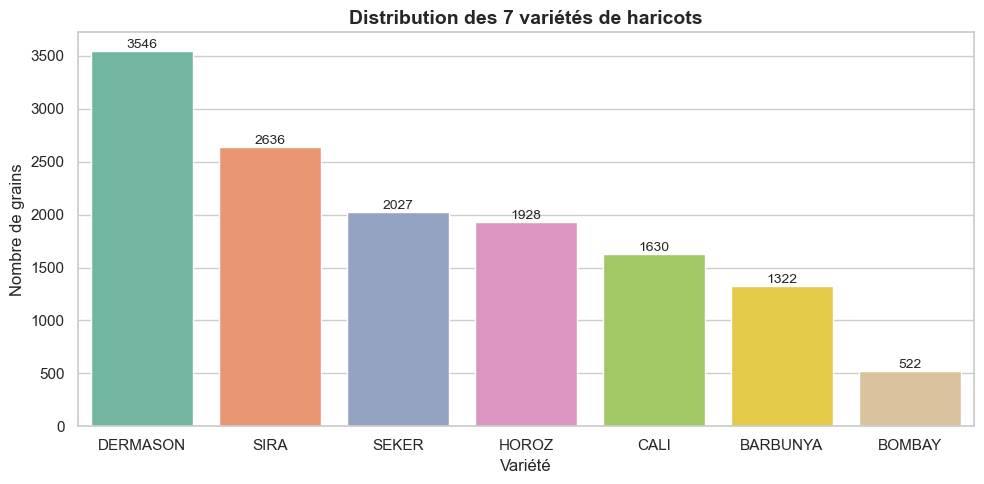

In [40]:
plt.figure(figsize=(10, 5))
ordre = df['Class'].value_counts().index
sns.countplot(data=df, x='Class', order=ordre, palette='Set2')
plt.title("Distribution des 7 variétés de haricots", fontsize=14, fontweight='bold')
plt.xlabel("Variété")
plt.ylabel("Nombre de grains")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("fig_01_distribution_classes.png", dpi=150)
plt.show()

DERMASON domine  avec environ 3 500 grains (26%), tandis que BOMBAY 
est très minoritaire (3.8%).
 d'ou ce déséquilibre explique pourquoi on utilise le F1-score macro et non l'accuracy comme métrique principale

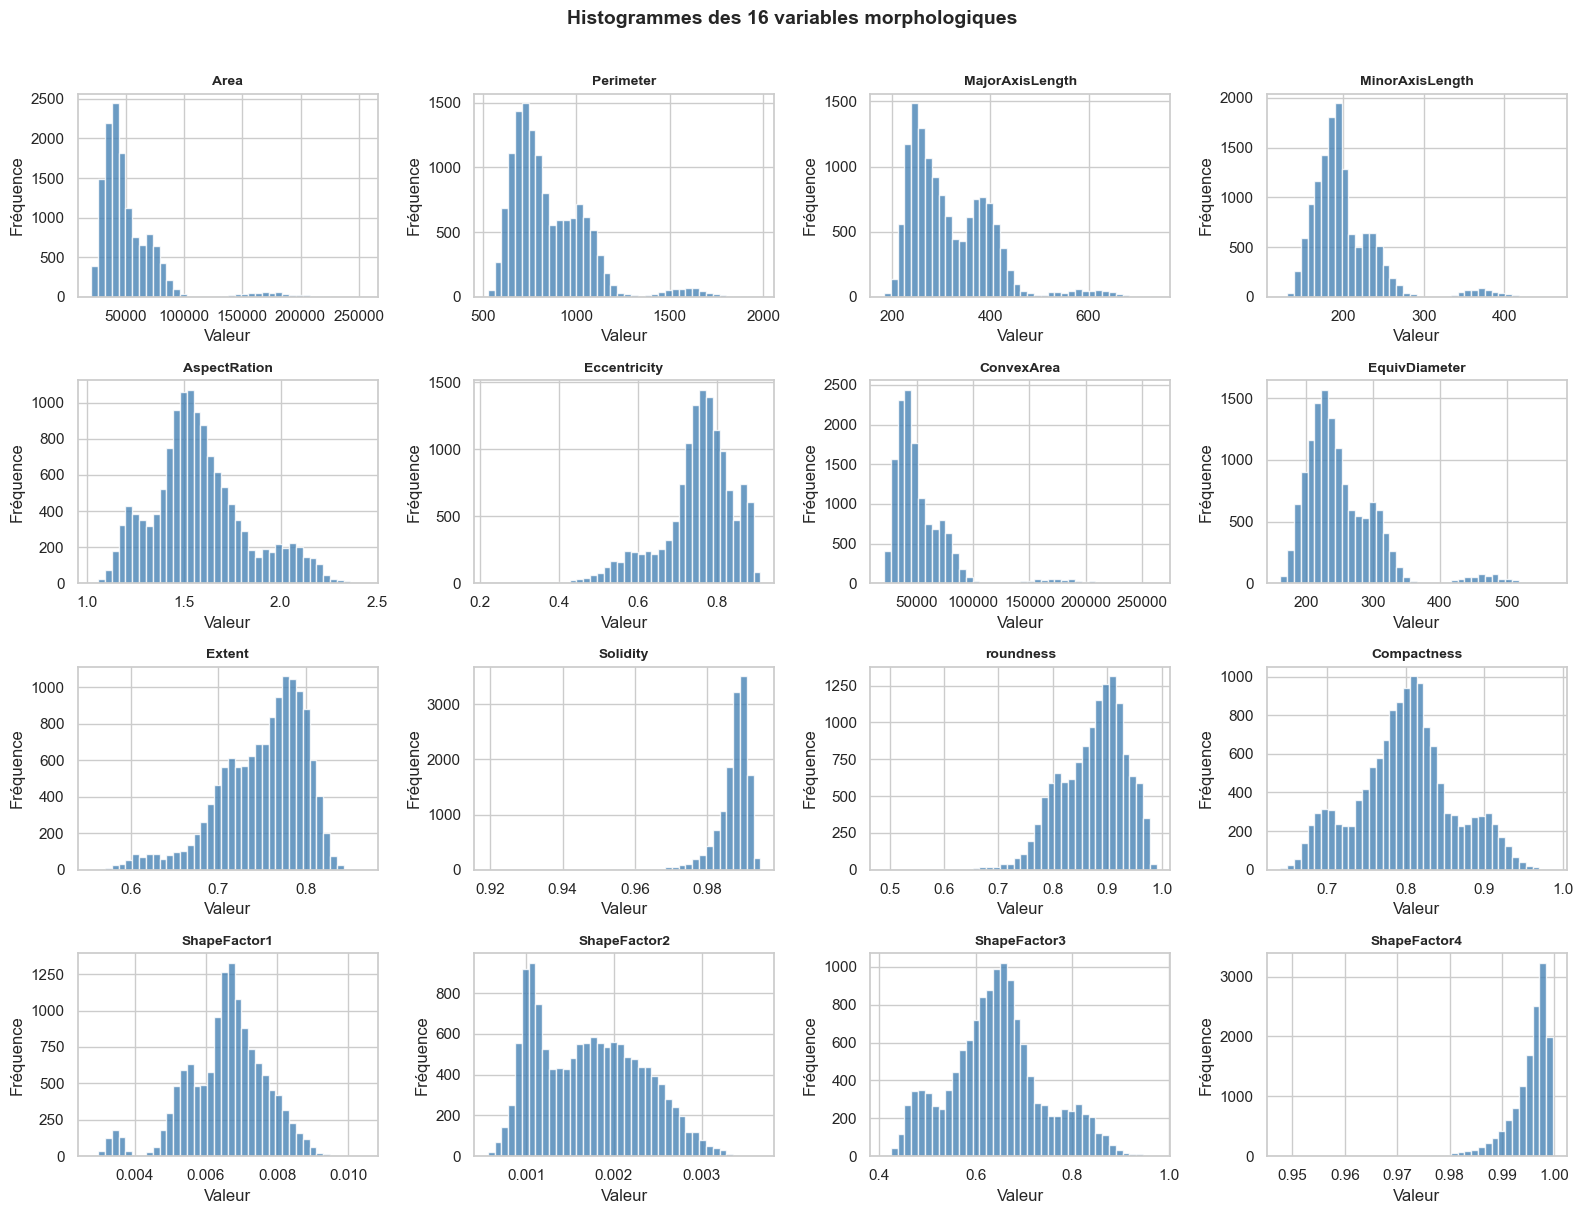

In [41]:
variables_num = df.drop(columns=['Class'])

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_num.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence")

plt.suptitle("Histogrammes des 16 variables morphologiques", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_02_histogrammes.png", dpi=150)
plt.show()

Les distributions sont généralement unimodales. Les variables de taille 
(Area, ConvexArea, Perimeter) montrent une asymétrie vers la droite, 
probablement par BOMBAY 

C:\Users\Malak\AppData\Local\Temp\ipykernel_55068\3584912519.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\Malak\AppData\Local\Temp\ipykernel_55068\3584912519.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\Malak\AppData\Local\Temp\ipykernel_55068\3584912519.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\Malak\AppData\Local\Temp\ipykernel

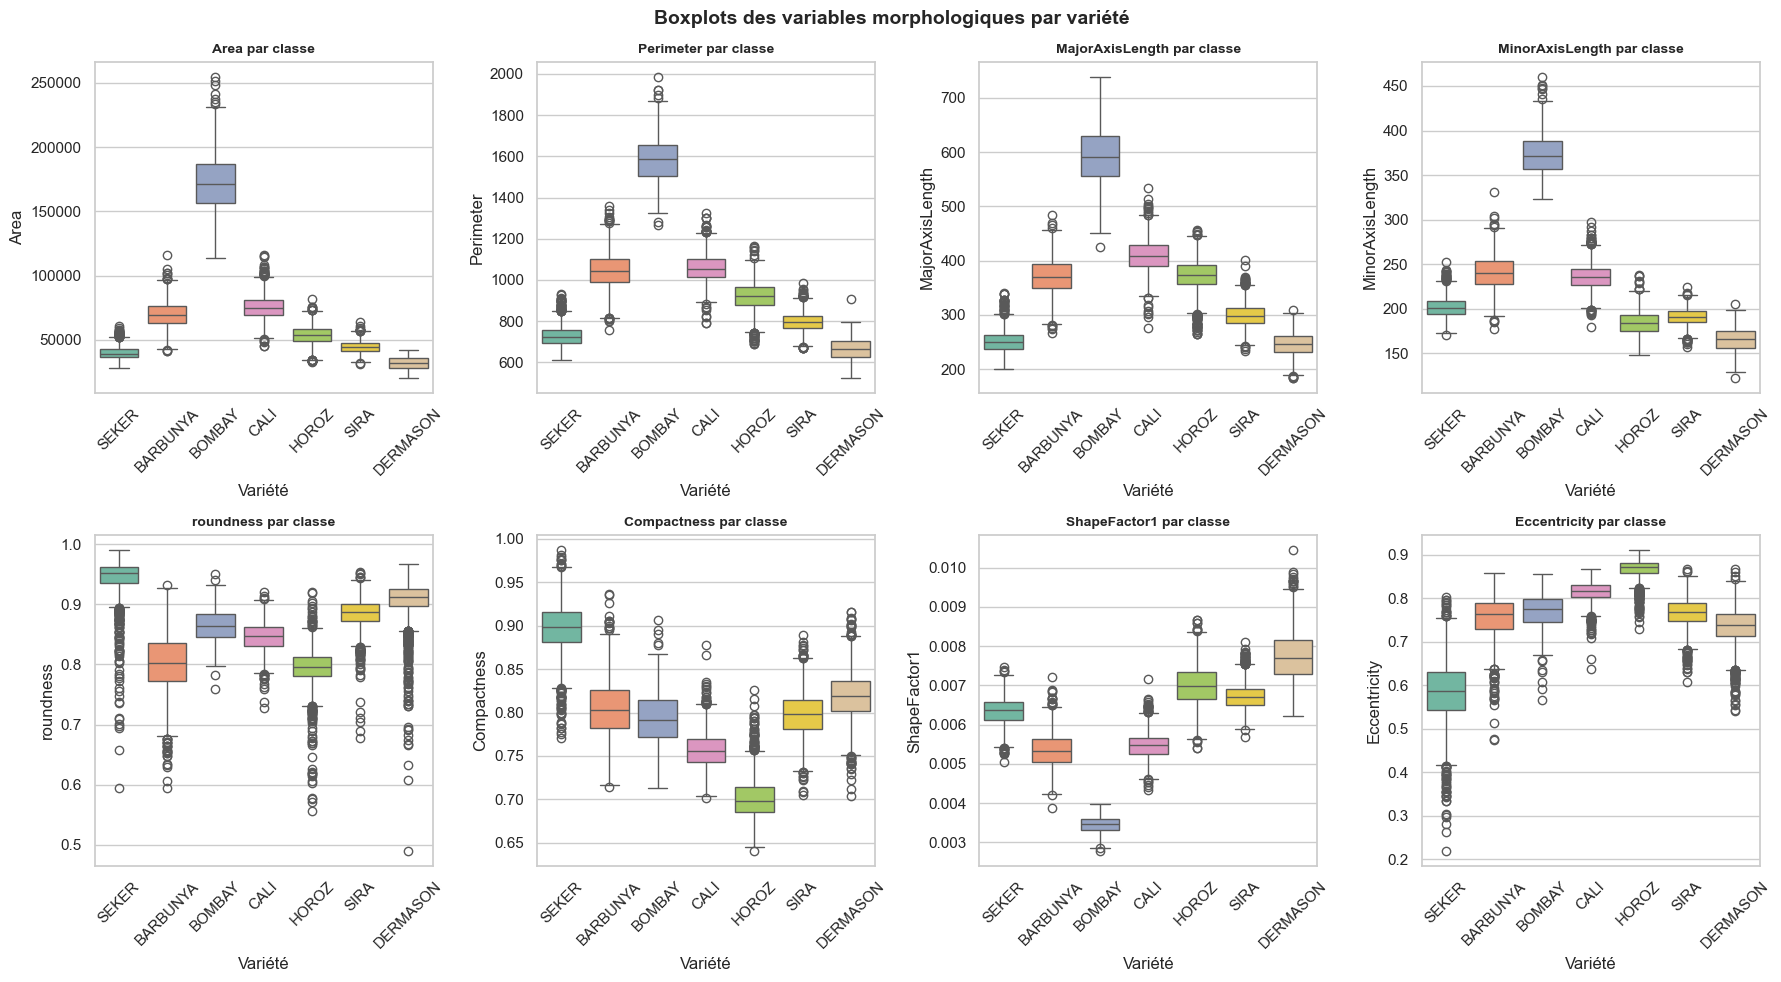

In [42]:
vars_boxplot = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'roundness', 'Compactness', 'ShapeFactor1', 'Eccentricity']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f"{col} par classe", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Variété")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Boxplots des variables morphologiques par variété", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_03_boxplots_classe.png", dpi=150)
plt.show()

BOMBAY se distingue immédiatement sur Area et Perimeter  ses grains sont plus grands que tous les autres. DERMASON et SIRA ont des distributions très proches 

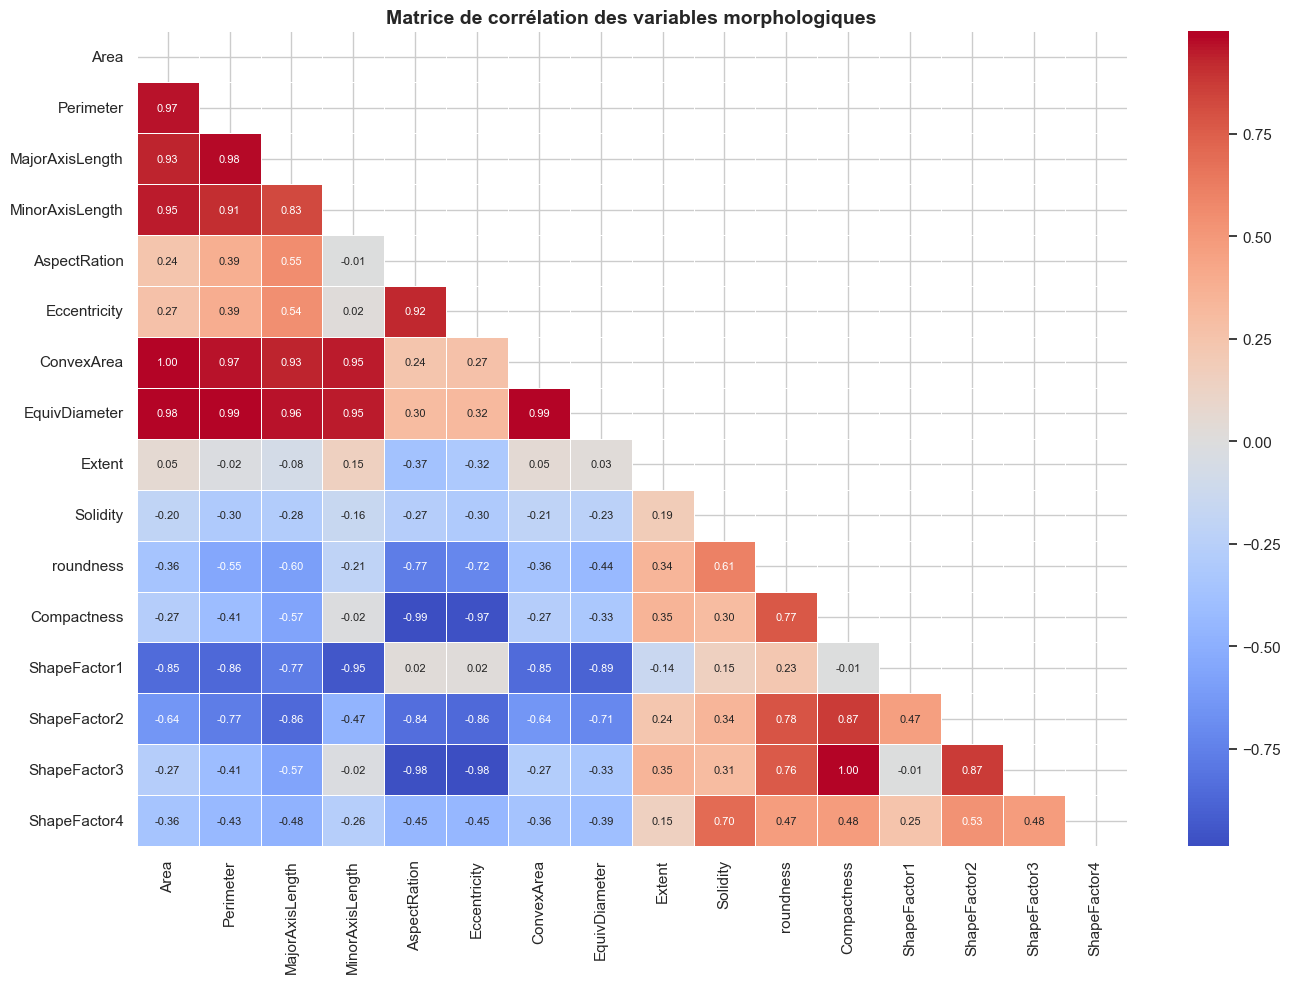

In [43]:
plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns=['Class']).corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Matrice de corrélation des variables morphologiques",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_04_correlation.png", dpi=150)
plt.show()

Les variables de taille (Area, Perimeter, ConvexArea, etc.) sont très 
corrélées entre elles (> 0.90). Les facteurs de forme forment un deuxième 
groupe. Ce qui justifie qu'on explore la PCA

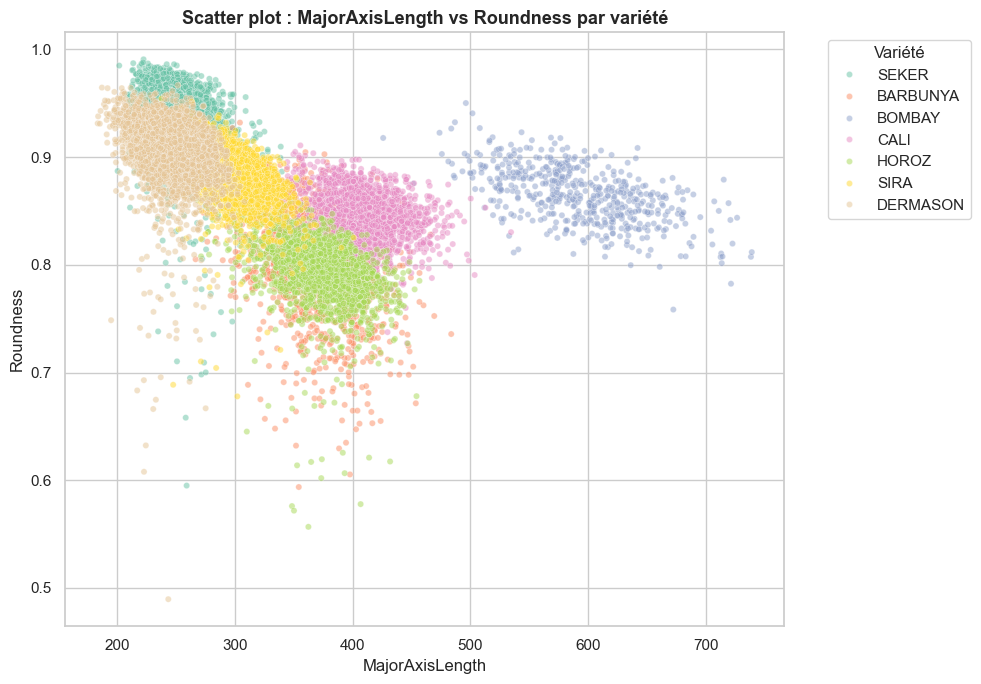

In [44]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='MajorAxisLength', y='roundness',
                hue='Class', palette='Set2', alpha=0.5, s=20)
plt.title("Scatter plot : MajorAxisLength vs Roundness par variété",
          fontsize=13, fontweight='bold')
plt.xlabel("MajorAxisLength")
plt.ylabel("Roundness")
plt.legend(title="Variété", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("fig_05_scatter.png", dpi=150)
plt.show()

Le graphique montre bien la séparation de BOMBAY ,  DERMASON et SIRA se chevauchent au centre, 
ce qui explique pourquoi ils sont si difficiles à discriminer 

In [45]:
import pandas as pd
import numpy as np

if 'df' not in globals():
    arff_path = 'DryBeanDataset/Dry_Bean_Dataset.arff'
    colonnes = [
        'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation',
        'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity',
        'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
        'ShapeFactor3', 'ShapeFactor4', 'Class'
    ]
    with open(arff_path, 'r', encoding='utf-8') as fichier:
        lignes = fichier.readlines()
    index_data = next(i for i, ligne in enumerate(lignes) if ligne.strip().lower() == '@data')
    df = pd.read_csv(arff_path, comment='%', skiprows=index_data + 1, header=None, names=colonnes)

In [46]:
missing_values = df.isnull().sum()
print("=== VALEURS MANQUANTES PAR COLONNE ===")
print(missing_values)
print(f"\nNombre total de valeurs manquantes : {missing_values.sum()}")

nb_doublons = df.duplicated().sum()
print(f"\nNombre de doublons détectés : {nb_doublons}")

if nb_doublons > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Doublons supprimés. Nouvelle taille : {df.shape[0]} lignes")
else:
    print("Aucun doublon détecté.")

variables_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = {}

for col in variables_numeriques:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    nb_outliers = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
    outlier_counts[col] = int(nb_outliers)

print("\n=== NOMBRE D'OUTLIERS PAR COLONNE (MÉTHODE IQR) ===")
for col, count in outlier_counts.items():
    print(f"{col:<18} : {count}")

print("\nConclusion : les outliers morphologiques sont conservés.")

=== VALEURS MANQUANTES PAR COLONNE ===
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Nombre total de valeurs manquantes : 0

Nombre de doublons détectés : 68
Doublons supprimés. Nouvelle taille : 13543 lignes

=== NOMBRE D'OUTLIERS PAR COLONNE (MÉTHODE IQR) ===
Area               : 551
Perimeter          : 500
MajorAxisLength    : 379
MinorAxisLength    : 567
AspectRation       : 485
Eccentricity       : 833
ConvexArea         : 549
EquivDiameter      : 526
Extent             : 271
Solidity           : 774
roundness          : 98
Compactness        : 124
ShapeFactor1       : 533
ShapeFactor2       : 0
ShapeFactor3       : 202
ShapeFactor4       : 760

Conclusion : le

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop(columns=['Class'])
y = df['Class']

le_encoder = LabelEncoder()
y_encoded = le_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("=== DISTRIBUTION DES CLASSES DANS LE TRAIN ===")
train_distribution = pd.Series(le_encoder.inverse_transform(y_train)).value_counts(normalize=True).sort_index()
print(train_distribution.mul(100).round(2).astype(str) + ' %')

print("\n=== DISTRIBUTION DES CLASSES DANS LE TEST ===")
test_distribution = pd.Series(le_encoder.inverse_transform(y_test)).value_counts(normalize=True).sort_index()
print(test_distribution.mul(100).round(2).astype(str) + ' %')

=== DISTRIBUTION DES CLASSES DANS LE TRAIN ===


BARBUNYA     9.76 %
BOMBAY       3.86 %
CALI        12.04 %
DERMASON    26.19 %
HOROZ       13.73 %
SEKER       14.96 %
SIRA        19.47 %
Name: proportion, dtype: object

=== DISTRIBUTION DES CLASSES DANS LE TEST ===
BARBUNYA     9.78 %
BOMBAY       3.84 %
CALI        12.03 %
DERMASON    26.17 %
HOROZ       13.73 %
SEKER       14.99 %
SIRA        19.45 %
Name: proportion, dtype: object


In [48]:
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

print("Préprocessing prêt : X_train, X_test, y_train, y_test et le_encoder sont disponibles.")

Préprocessing prêt : X_train, X_test, y_train, y_test et le_encoder sont disponibles.


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {}
predictions = {}

model_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

In [50]:
for model_name, model in model_configs.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    models[model_name] = pipeline
    predictions[model_name] = y_pred

    print(f"{model_name:<20} | Accuracy test : {test_accuracy:.4f}")

Logistic Regression  | Accuracy test : 0.9192
KNN                  | Accuracy test : 0.9155
Decision Tree        | Accuracy test : 0.8966
Random Forest        | Accuracy test : 0.9195



Modèle : Logistic Regression
Accuracy   : 0.9192
F1 macro   : 0.9302
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



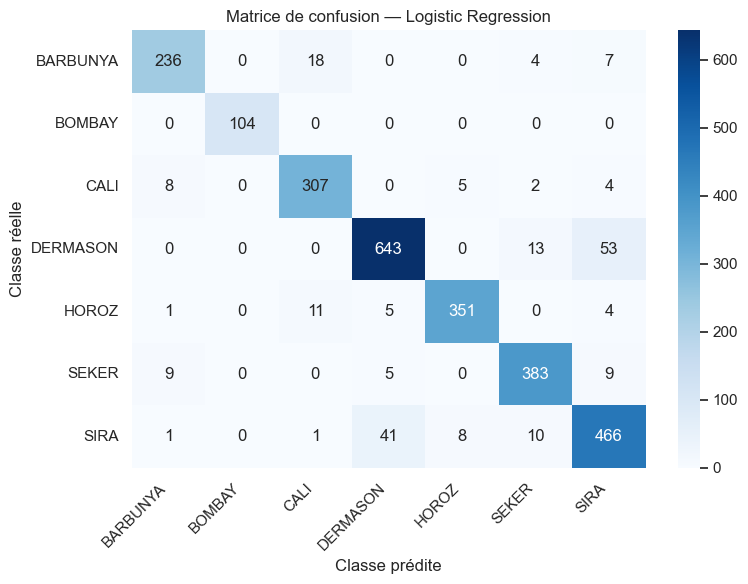


Modèle : KNN
Accuracy   : 0.9155
F1 macro   : 0.9270
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



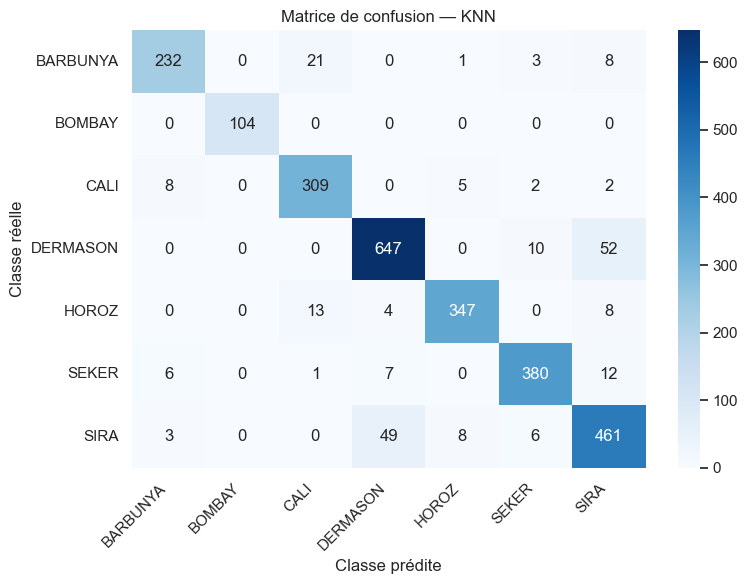


Modèle : Decision Tree
Accuracy   : 0.8966
F1 macro   : 0.9109
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.90      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.91      0.91       326
    DERMASON       0.89      0.91      0.90       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.91      0.94      0.92       406
        SIRA       0.84      0.81      0.82       527

    accuracy                           0.90      2709
   macro avg       0.91      0.91      0.91      2709
weighted avg       0.90      0.90      0.90      2709



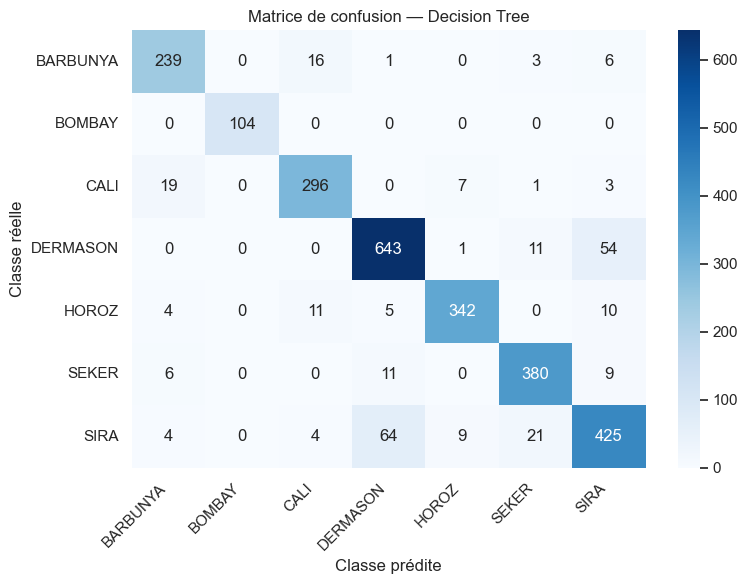


Modèle : Random Forest
Accuracy   : 0.9195
F1 macro   : 0.9312
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



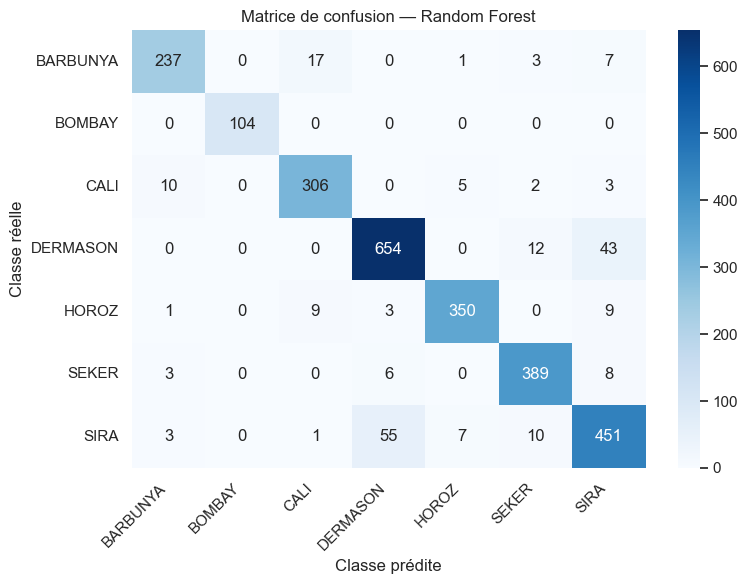


Tableau comparatif final des modèles :


,Modèle,Accuracy,F1 macro
0,Random Forest,0.92,0.93
1,Logistic Regression,0.92,0.93
2,KNN,0.92,0.93
3,Decision Tree,0.90,0.91


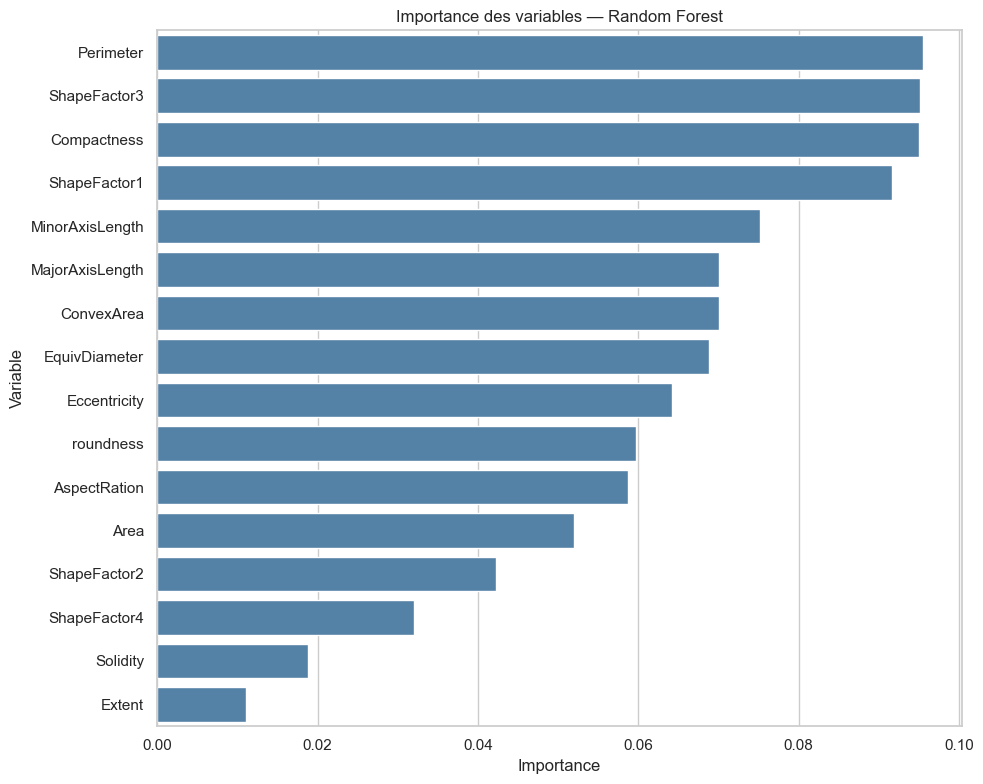


Variables les plus discriminantes : Perimeter, ShapeFactor3, Compactness


In [51]:
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

comparison_rows = []
confusion_matrices = {}
for model_name, pipeline in models.items():
    y_pred_model = predictions[model_name]
    acc = accuracy_score(y_test, y_pred_model)
    f1_macro = f1_score(y_test, y_pred_model, average='macro')
    cm = confusion_matrix(y_test, y_pred_model)

    comparison_rows.append({
        'Modèle': model_name,
        'Accuracy': acc,
        'F1 macro': f1_macro,
    })
    confusion_matrices[model_name] = cm

    print(f"\nModèle : {model_name}")
    print(f"Accuracy   : {acc:.4f}")
    print(f"F1 macro   : {f1_macro:.4f}")
    print("Rapport de classification :")
    print(classification_report(y_test, y_pred_model, target_names=le_encoder.classes_, zero_division=0))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le_encoder.classes_,
        yticklabels=le_encoder.classes_
    )
    plt.title(f"Matrice de confusion — {model_name}")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

comparison_df = pd.DataFrame(comparison_rows).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print("\nTableau comparatif final des modèles :")
display(comparison_df)

rf_pipeline = models['Random Forest']
rf_model = rf_pipeline.named_steps['model']
feature_importances = (
    pd.DataFrame({
        'Variable': X_train.columns,
        'Importance': rf_model.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances, x='Importance', y='Variable', color='steelblue')
plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

top_variables = feature_importances.head(5)['Variable'].tolist()
print(f"\nVariables les plus discriminantes : {', '.join(top_variables[:3])}")

Le Perimeter est la variable la plus importante, suivi de ShapeFactor3 et 
Compactness. Les variables de taille et de forme jouent un rôle significatif et aucune variable n'est négligeable.

In [55]:
from IPython.display import display
import numpy as np
import pandas as pd

best_row = comparison_df.iloc[0]
best_model_name = best_row['Modèle']
best_f1_macro = best_row['F1 macro']
best_accuracy = best_row['Accuracy']
best_cm = confusion_matrices[best_model_name]

print(f"Meilleur modèle : {best_model_name}")
print(f"F1-score macro : {best_f1_macro:.4f}")
print(f"Accuracy : {best_accuracy:.4f}")
print("\nLa sélection se fait sur le F1 macro car il est plus robuste au léger")
print("déséquilibre des classes et reflète mieux la qualité multiclasses.")

confusion_pairs = []
for i in range(len(le_encoder.classes_)):
    for j in range(i + 1, len(le_encoder.classes_)):
        total_confusion = int(best_cm[i, j] + best_cm[j, i])
        confusion_pairs.append((total_confusion, i, j))

most_confused_total, class_i, class_j = max(confusion_pairs, key=lambda item: item[0])
class_a = le_encoder.classes_[class_i]
class_b = le_encoder.classes_[class_j]

print(f"\nClasses les plus confondues : {class_a} et {class_b}")
print(f"Nombre de confusions croisées : {most_confused_total}")
print("Explication : ces deux variétés présentent des formes globales proches")
print("avec des valeurs morphologiques qui se chevauchent.")

confusion_summary = pd.DataFrame({
    'Classe 1': [class_a],
    'Classe 2': [class_b],
    'Confusions croisées': [most_confused_total],
})
display(confusion_summary)

Meilleur modèle : Random Forest
F1-score macro : 0.9312
Accuracy : 0.9195

La sélection se fait sur le F1 macro car il est plus robuste au léger
déséquilibre des classes et reflète mieux la qualité multiclasses.

Classes les plus confondues : DERMASON et SIRA
Nombre de confusions croisées : 98
Explication : ces deux variétés présentent des formes globales proches
avec des valeurs morphologiques qui se chevauchent.


,Classe 1,Classe 2,Confusions croisées
0,DERMASON,SIRA,98


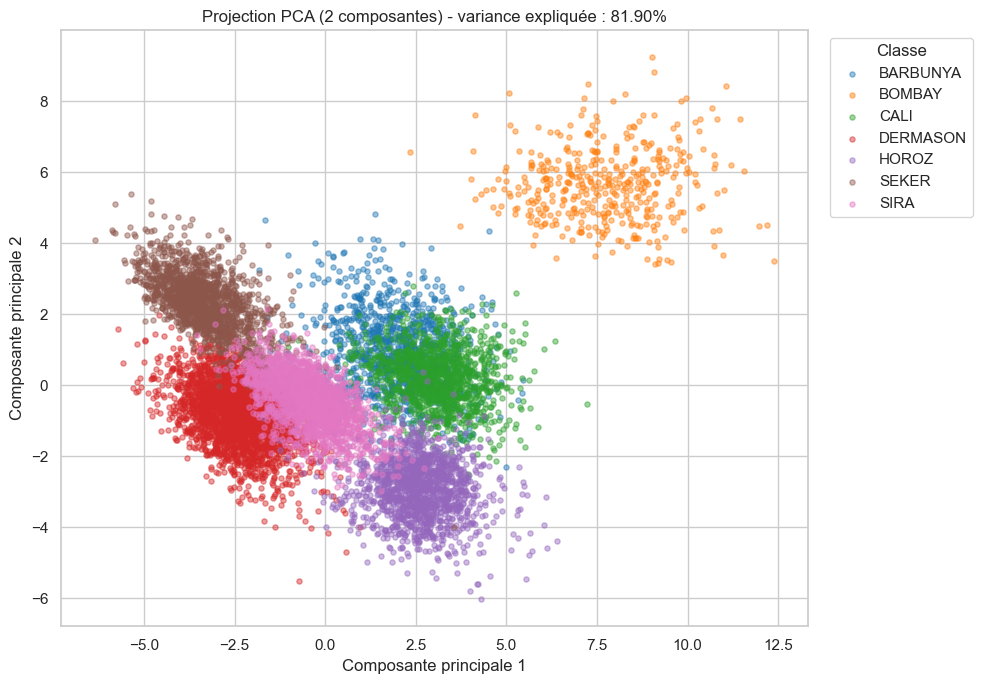

Variance expliquée par 2 composantes : 81.90%

Comparaison F1 macro avec PCA vs sans PCA :


,Modèle,F1 macro sans PCA,F1 macro avec PCA,Écart PCA
0,Random Forest,0.93,0.85,-0.08
1,Logistic Regression,0.93,0.87,-0.06
2,KNN,0.93,0.84,-0.08
3,Decision Tree,0.91,0.80,-0.11


In [56]:
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42)),
])

X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)

explained_variance = pca_pipeline.named_steps['pca'].explained_variance_ratio_

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=len(le_encoder.classes_))
y_train_array = np.asarray(y_train)

for class_index, class_name in enumerate(le_encoder.classes_):
    mask = y_train_array == class_index
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        s=14,
        alpha=0.45,
        color=palette[class_index],
        label=class_name,
    )

plt.title(f"Projection PCA (2 composantes) - variance expliquée : {explained_variance.sum():.2%}")
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend(title='Classe', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"Variance expliquée par 2 composantes : {explained_variance.sum():.2%}")

pca_model_results = []
pca_models = {}
pca_predictions = {}

for model_name, pipeline in models.items():
    estimator = clone(pipeline.named_steps['model'])
    estimator.fit(X_train_pca, y_train)
    y_pred_pca = estimator.predict(X_test_pca)
    pca_models[model_name] = estimator
    pca_predictions[model_name] = y_pred_pca
    pca_model_results.append({
        'Modèle': model_name,
        'F1 macro avec PCA': f1_score(y_test, y_pred_pca, average='macro'),
    })

pca_results_df = pd.DataFrame(pca_model_results)
original_scores = comparison_df[['Modèle', 'F1 macro']].rename(columns={'F1 macro': 'F1 macro sans PCA'})
comparison_pca_df = (
    original_scores
    .merge(pca_results_df, on='Modèle', how='inner')
    .sort_values('F1 macro sans PCA', ascending=False)
    .reset_index(drop=True)
)
comparison_pca_df['Écart PCA'] = comparison_pca_df['F1 macro avec PCA'] - comparison_pca_df['F1 macro sans PCA']

print("\nComparaison F1 macro avec PCA vs sans PCA :")
display(comparison_pca_df)